--- 5 Data Teratas ---


,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Wasting
0,Laki-laki,19,91.6,13.3,Tall,Risk of Overweight
1,Laki-laki,20,77.7,8.5,Stunted,Underweight
2,Laki-laki,10,79.0,10.3,Normal,Risk of Overweight
3,Perempuan,2,50.3,8.3,Severely Stunted,Risk of Overweight
4,Perempuan,5,56.4,10.9,Severely Stunted,Risk of Overweight


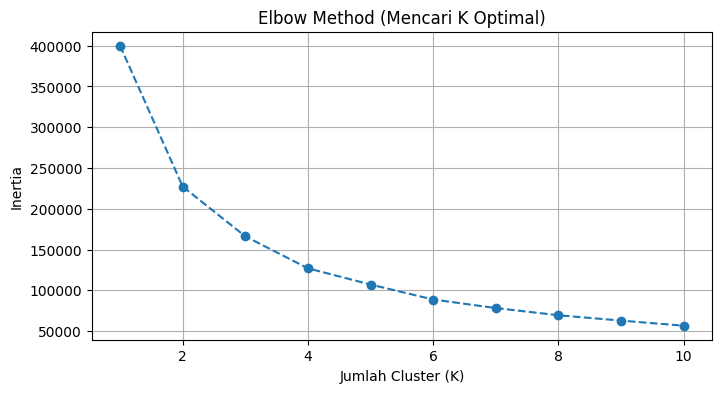

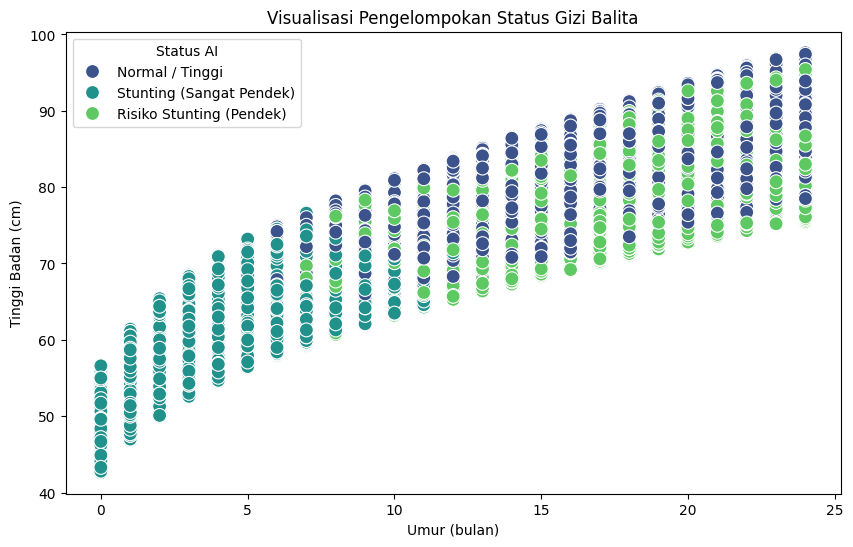


--- HASIL UJI COBA ---
Input: Umur 25 bln, Tinggi 25 cm, Berat 5 kg
Hasil AI: Stunting (Sangat Pendek)

--- Sampel Hasil Analisis Akhir ---


c:\Users\Dede\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Jenis Kelamin,Umur (bulan),Tinggi Badan (cm),Berat Badan (kg),Stunting,Kategori_AI
0,Laki-laki,19,91.6,13.3,Tall,Normal / Tinggi
1,Laki-laki,20,77.7,8.5,Stunted,Normal / Tinggi
2,Laki-laki,10,79.0,10.3,Normal,Normal / Tinggi
3,Perempuan,2,50.3,8.3,Severely Stunted,Stunting (Sangat Pendek)
4,Perempuan,5,56.4,10.9,Severely Stunted,Stunting (Sangat Pendek)
5,Laki-laki,11,76.3,5.9,Normal,Normal / Tinggi
6,Laki-laki,16,80.7,9.9,Normal,Normal / Tinggi
7,Perempuan,15,72.6,6.5,Normal,Risiko Stunting (Pendek)
8,Perempuan,18,78.4,15.6,Normal,Risiko Stunting (Pendek)
9,Laki-laki,2,63.4,7.0,Normal,Stunting (Sangat Pendek)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score

# 1. LOAD DATASET
df = pd.read_csv('stunting_wasting_dataset.csv')

print("--- 5 Data Teratas ---")
display(df.head())

# 2. PREPROCESSING
# Mengubah Jenis Kelamin menjadi numerik
le = LabelEncoder()
df['JK_Enc'] = le.fit_transform(df['Jenis Kelamin'])

# Memilih fitur sesuai dataset
features = ['Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)', 'JK_Enc']
X = df[features]

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. MENENTUKAN JUMLAH CLUSTER (ELBOW METHOD)
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method (Mencari K Optimal)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# 4. IMPLEMENTASI K-MEANS (K=3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. LOGIKA SORTING CLUSTER
cluster_order = df.groupby('Cluster')['Tinggi Badan (cm)'].mean().sort_values().index
kategori_map = {
    cluster_order[0]: "Stunting (Sangat Pendek)",
    cluster_order[1]: "Risiko Stunting (Pendek)",
    cluster_order[2]: "Normal / Tinggi"
}
df['Kategori_AI'] = df['Cluster'].map(kategori_map)

# 6. VISUALISASI HASIL CLUSTERING
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Umur (bulan)', y='Tinggi Badan (cm)', hue='Kategori_AI', palette='viridis', s=100)
plt.title('Visualisasi Pengelompokan Status Gizi Balita')
plt.legend(title='Status AI')
plt.show()

# 7. FUNGSI PREDIKSI UNTUK TESTING
def cek_stunting(umur, tinggi, berat, jk_teks):
    # Mapping jenis kelamin ke angka sesuai LabelEncoder
    jk_val = 0 if jk_teks.lower() == 'laki-laki' else 1
    
    # Preprocessing input
    input_data = np.array([[umur, tinggi, berat, jk_val]])
    input_scaled = scaler.transform(input_data)
    
    # Prediksi
    cluster_res = kmeans.predict(input_scaled)[0]
    return kategori_map[cluster_res]

# UJI COBA
print("\n--- HASIL UJI COBA ---")
test_umur = 25
test_tinggi = 25
test_berat = 5
hasil = cek_stunting(test_umur, test_tinggi, test_berat, 'laki-laki')
print(f"Input: Umur {test_umur} bln, Tinggi {test_tinggi} cm, Berat {test_berat} kg")
print(f"Hasil AI: {hasil}")

# 8. MENAMPILKAN HASIL AKHIR DALAM TABEL
print("\n--- Sampel Hasil Analisis Akhir ---")
kolom_tampil = ['Jenis Kelamin', 'Umur (bulan)', 'Tinggi Badan (cm)', 'Berat Badan (kg)', 'Stunting', 'Kategori_AI']
display(df[kolom_tampil].head(10))